<a href="https://colab.research.google.com/github/Sandesh-reg/HIT140-Assignment-2_Foundation-of-Data-Science/blob/Aadesh_code/Aadesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
!pip install xlrd

In [4]:
df = pd.read_csv("new data.csv", encoding="latin1")
print(df.head())
print(df.shape)
print(df.columns)


   Rk              Player Pos      Squad  Age  Born  MP  Min  90s  Gls
0   1    Brenden Aaronson  MF     us USA   25  2000   1   76  0.8    0
1   2      Thelo Aasgaard  MF  no Norway   24  2002   1   90  1.0    1
2   3    Hamza Abdelkarim  FW   eg Egypt   18  2008   4   60  0.7    0
3   4  Hossam Abdelmaguid  DF   eg Egypt   25  2001   2   59  0.7    0
4   5  Mohamed Abdelmonem  DF   eg Egypt   27  1999   2   14  0.2    0
(498, 10)
Index(['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', 'MP', 'Min', '90s',
       'Gls'],
      dtype='object')


In [5]:
df.shape

(498, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      498 non-null    int64  
 1   Player  498 non-null    object 
 2   Pos     498 non-null    object 
 3   Squad   498 non-null    object 
 4   Age     498 non-null    int64  
 5   Born    498 non-null    int64  
 6   MP      498 non-null    int64  
 7   Min     498 non-null    int64  
 8   90s     498 non-null    float64
 9   Gls     498 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 39.0+ KB


In [7]:
df.describe()


,Rk,Age,Born,MP,Min,90s,Gls
count,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000
mean,249.500000,27.271084,1998.218876,3.038153,198.030120,2.199197,0.267068
std,143.904482,4.053566,4.064654,1.572062,153.527172,1.703328,0.821590
min,1.000000,18.000000,1986.000000,1.000000,1.000000,0.000000,0.000000
25%,125.250000,24.000000,1995.250000,2.000000,71.250000,0.800000,0.000000
50%,249.500000,27.000000,1998.000000,3.000000,179.000000,2.000000,0.000000
75%,373.750000,30.000000,2001.000000,4.000000,270.000000,3.000000,0.000000
max,498.000000,40.000000,2008.000000,8.000000,750.000000,8.300000,7.000000


In [8]:
df.isnull().sum()

,0
Rk,0
Player,0
Pos,0
Squad,0
Age,0
Born,0
MP,0
Min,0
90s,0
Gls,0


In [10]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Gls"] = pd.to_numeric(df["Gls"], errors="coerce")
df["MP"] = pd.to_numeric(df["MP"], errors="coerce")
df["Min"] = pd.to_numeric(df["Min"], errors="coerce")
df["90s"] = pd.to_numeric(df["90s"], errors="coerce")

In [11]:
df = df.dropna(subset=["Age", "Gls"])

In [12]:
df.isnull().sum()

,0
Rk,0
Player,0
Pos,0
Squad,0
Age,0
Born,0
MP,0
Min,0
90s,0
Gls,0


In [13]:
goal_scorers = df[df["Gls"] > 0]

non_scorers = df[df["Gls"] == 0]

In [14]:
print("Goal scorers:", len(goal_scorers))
print("Non-scorers:", len(non_scorers))

Goal scorers: 77
Non-scorers: 421


In [15]:
scorers_age = goal_scorers["Age"]
non_scorers_age = non_scorers["Age"]

print("Scorers' ages:")
print(scorers_age.tolist())

print("\nNon-scorers' ages:")
print(non_scorers_age.tolist())

Scorers' ages:
[24, 18, 26, 26, 29, 22, 26, 28, 37, 28, 22, 31, 24, 24, 23, 23, 24, 22, 26, 25, 24, 22, 34, 26, 27, 34, 22, 28, 22, 27, 26, 24, 34, 25, 29, 23, 22, 29, 29, 21, 26, 24, 29, 22, 29, 22, 25, 29, 21, 27, 24, 25, 26, 27, 21, 28, 25, 27, 27, 35, 26, 30, 25, 33, 29, 20, 26, 25, 33, 35, 25, 26, 28, 29, 32, 29, 35]

Non-scorers' ages:
[25, 18, 25, 27, 32, 26, 28, 26, 26, 31, 23, 25, 33, 26, 27, 29, 25, 27, 36, 25, 24, 22, 29, 29, 28, 31, 25, 26, 25, 28, 30, 31, 25, 24, 27, 33, 33, 26, 29, 29, 24, 25, 27, 29, 30, 33, 25, 32, 33, 27, 28, 21, 25, 30, 29, 28, 28, 26, 29, 22, 23, 27, 27, 29, 24, 27, 24, 30, 24, 24, 30, 29, 25, 34, 33, 29, 29, 27, 30, 35, 25, 34, 24, 22, 28, 34, 21, 35, 34, 29, 32, 21, 31, 24, 29, 26, 22, 29, 22, 35, 23, 33, 27, 27, 27, 31, 25, 31, 24, 31, 31, 28, 28, 28, 20, 27, 21, 28, 24, 22, 26, 30, 22, 23, 18, 26, 35, 23, 35, 26, 37, 30, 32, 30, 27, 26, 30, 34, 28, 24, 28, 25, 26, 26, 28, 24, 30, 32, 22, 30, 29, 32, 24, 30, 25, 22, 29, 25, 23, 26, 23, 24, 30, 30,

In [16]:
sample = df.sample(n=60, random_state=42)

print("Sample size:", len(sample))
sample.head()

Sample size: 60


,Rk,Player,Pos,Squad,Age,Born,MP,Min,90s,Gls
487,488,Rani Khedira,MF,tn Tunisia,32,1994,3,149,1.7,0
73,74,Yazan Al-Arab,DF,jo Jordan,30,1996,3,270,3.0,0
231,232,Salem Al-Dawsari,MF,sa Saudi Arabia,34,1991,3,245,2.7,0
175,176,Jo?o Cancelo,DF,pt Portugal,32,1994,5,312,3.5,0
237,238,Nicol s De La Cruz,MF,uy Uruguay,29,1997,3,86,1.0,0


In [17]:
sample[["Player", "Age", "Gls"]].head(10)

,Player,Age,Gls
487,Rani Khedira,32,0
73,Yazan Al-Arab,30,0
231,Salem Al-Dawsari,34,0
175,Jo?o Cancelo,32,0
237,Nicol s De La Cruz,29,0
424,Yang Hyun-jun,24,0
155,Nathaniel Brown,22,1
55,Ayoube Amaimouni,21,0
322,Jassem Gaber,24,0
9,Husam Abu Dahab,26,0


In [18]:
descriptive_stats = df.groupby(
    df["Gls"] > 0
)["Age"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

descriptive_stats

,count,mean,median,std,min,max
Gls,,,,,,
False,421,27.410926,27.0,4.053191,18,40
True,77,26.506494,26.0,3.995469,18,37


In [19]:
descriptive_stats.index = [
    "Non-scorers",
    "Goal scorers"
]

descriptive_stats

,count,mean,median,std,min,max
Non-scorers,421,27.410926,27.0,4.053191,18,40
Goal scorers,77,26.506494,26.0,3.995469,18,37


In [20]:
print("Goal scorers")
print("Number of players:", len(scorers_age))
print("Mean age:", scorers_age.mean())
print("Median age:", scorers_age.median())
print("Standard deviation:", scorers_age.std())
print("Minimum age:", scorers_age.min())
print("Maximum age:", scorers_age.max())

Goal scorers
Number of players: 77
Mean age: 26.506493506493506
Median age: 26.0
Standard deviation: 3.9954690674608186
Minimum age: 18
Maximum age: 37


In [21]:
print("Non-scorers")
print("Number of players:", len(non_scorers_age))
print("Mean age:", non_scorers_age.mean())
print("Median age:", non_scorers_age.median())
print("Standard deviation:", non_scorers_age.std())
print("Minimum age:", non_scorers_age.min())
print("Maximum age:", non_scorers_age.max())

Non-scorers
Number of players: 421
Mean age: 27.410926365795724
Median age: 27.0
Standard deviation: 4.053190906033857
Minimum age: 18
Maximum age: 40


In [22]:
mean_scorers = scorers_age.mean()
mean_non_scorers = non_scorers_age.mean()

difference = mean_scorers - mean_non_scorers

print("Mean age of goal scorers:", round(mean_scorers, 2))
print("Mean age of non-scorers:", round(mean_non_scorers, 2))
print("Difference in mean age:", round(difference, 2))

Mean age of goal scorers: 26.51
Mean age of non-scorers: 27.41
Difference in mean age: -0.9


/tmp/ipykernel_535/1617002684.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


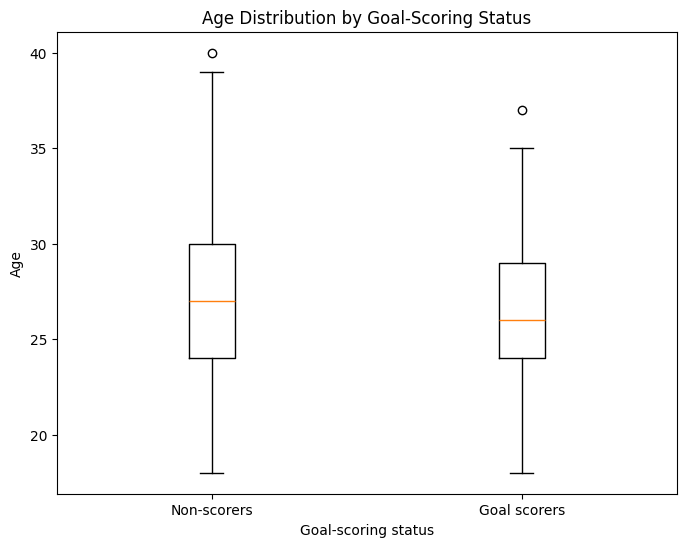

In [23]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [non_scorers_age, scorers_age],
    labels=["Non-scorers", "Goal scorers"]
)

plt.title("Age Distribution by Goal-Scoring Status")
plt.ylabel("Age")
plt.xlabel("Goal-scoring status")

plt.show()

In [24]:
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    standard_error = stats.sem(data)

    margin_of_error = (
        standard_error *
        stats.t.ppf((1 + confidence) / 2, n - 1)
    )

    lower = mean - margin_of_error
    upper = mean + margin_of_error

    return lower, upper

In [25]:
scorers_ci = confidence_interval(scorers_age)

print("95% Confidence Interval for Goal Scorers")
print("Lower:", round(scorers_ci[0], 2))
print("Upper:", round(scorers_ci[1], 2))

95% Confidence Interval for Goal Scorers
Lower: 25.6
Upper: 27.41


In [26]:
non_scorers_ci = confidence_interval(non_scorers_age)

print("95% Confidence Interval for Non-scorers")
print("Lower:", round(non_scorers_ci[0], 2))
print("Upper:", round(non_scorers_ci[1], 2))

95% Confidence Interval for Non-scorers
Lower: 27.02
Upper: 27.8


In [27]:
ci_table = pd.DataFrame({
    "Group": ["Goal scorers", "Non-scorers"],
    "Mean Age": [
        scorers_age.mean(),
        non_scorers_age.mean()
    ],
    "CI Lower": [
        scorers_ci[0],
        non_scorers_ci[0]
    ],
    "CI Upper": [
        scorers_ci[1],
        non_scorers_ci[1]
    ]
})

ci_table.round(2)

,Group,Mean Age,CI Lower,CI Upper
0,Goal scorers,26.51,25.60,27.41
1,Non-scorers,27.41,27.02,27.80


In [29]:
alpha = 0.05
t_statistic, p_value = stats.ttest_ind(
    scorers_age,
    non_scorers_age,
    equal_var=False
)

print("T-statistic:", round(t_statistic, 4))
print("P-value:", round(p_value, 4))

T-statistic: -1.8222
P-value: 0.0712


In [30]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average age.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average age.")

Fail to reject the null hypothesis.
There is no statistically significant difference in average age.


In [31]:
mean_difference = scorers_age.mean() - non_scorers_age.mean()

print(
    "Difference in mean age:",
    round(mean_difference, 2),
    "years"
)

Difference in mean age: -0.9 years


In [32]:
final_results = pd.DataFrame({
    "Group": [
        "Goal scorers",
        "Non-scorers"
    ],
    "Sample Size": [
        len(scorers_age),
        len(non_scorers_age)
    ],
    "Mean Age": [
        scorers_age.mean(),
        non_scorers_age.mean()
    ],
    "Median Age": [
        scorers_age.median(),
        non_scorers_age.median()
    ],
    "Std Dev": [
        scorers_age.std(),
        non_scorers_age.std()
    ],
    "95% CI Lower": [
        scorers_ci[0],
        non_scorers_ci[0]
    ],
    "95% CI Upper": [
        scorers_ci[1],
        non_scorers_ci[1]
    ]
})

final_results.round(2)

,Group,Sample Size,Mean Age,Median Age,Std Dev,95% CI Lower,95% CI Upper
0,Goal scorers,77,26.51,26.0,4.00,25.60,27.41
1,Non-scorers,421,27.41,27.0,4.05,27.02,27.80


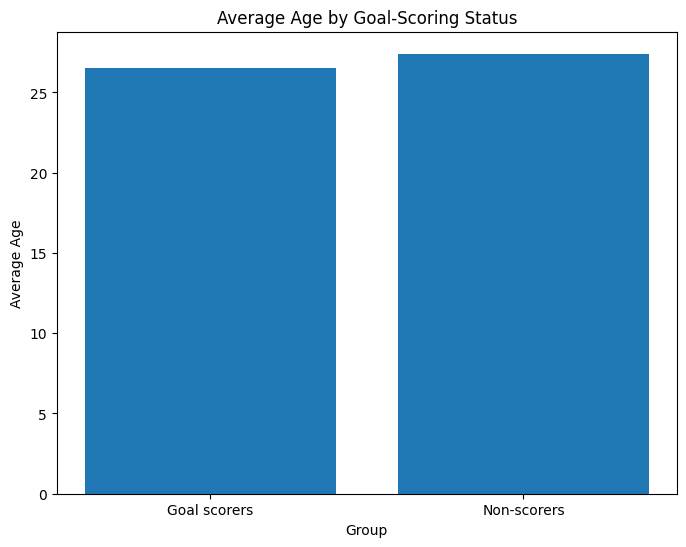

In [33]:
means = [
    scorers_age.mean(),
    non_scorers_age.mean()
]

groups = [
    "Goal scorers",
    "Non-scorers"
]

plt.figure(figsize=(8, 6))

plt.bar(groups, means)

plt.title("Average Age by Goal-Scoring Status")
plt.xlabel("Group")
plt.ylabel("Average Age")

plt.show()

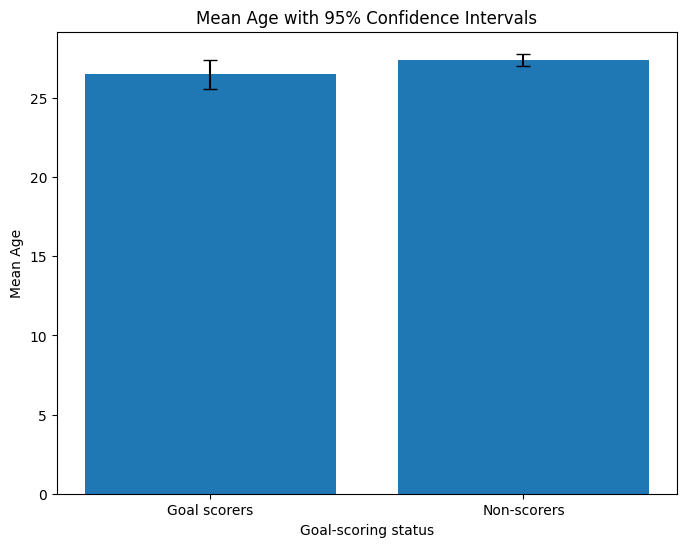

In [34]:
means = np.array([
    scorers_age.mean(),
    non_scorers_age.mean()
])

lower_errors = np.array([
    scorers_age.mean() - scorers_ci[0],
    non_scorers_age.mean() - non_scorers_ci[0]
])

upper_errors = np.array([
    scorers_ci[1] - scorers_age.mean(),
    non_scorers_ci[1] - non_scorers_age.mean()
])

errors = np.array([
    lower_errors,
    upper_errors
])

plt.figure(figsize=(8, 6))

plt.bar(
    ["Goal scorers", "Non-scorers"],
    means,
    yerr=errors,
    capsize=5
)

plt.title("Mean Age with 95% Confidence Intervals")
plt.xlabel("Goal-scoring status")
plt.ylabel("Mean Age")

plt.show()

In [35]:
print("FINAL CONCLUSION")
print("-----------------")

print(
    f"Goal scorers had an average age of "
    f"{scorers_age.mean():.2f} years."
)

print(
    f"Non-scorers had an average age of "
    f"{non_scorers_age.mean():.2f} years."
)

print(
    f"The difference in average age was "
    f"{abs(mean_difference):.2f} years."
)

print(
    f"The Welch two-sample t-test produced a "
    f"p-value of {p_value:.4f}."
)

if p_value < 0.05:
    print(
        "Since the p-value is less than 0.05, "
        "we reject the null hypothesis."
    )
    print(
        "There is a statistically significant difference "
        "in average age between the two groups."
    )
else:
    print(
        "Since the p-value is greater than 0.05, "
        "we fail to reject the null hypothesis."
    )
    print(
        "There is no statistically significant difference "
        "in average age between the two groups."
    )

FINAL CONCLUSION
-----------------
Goal scorers had an average age of 26.51 years.
Non-scorers had an average age of 27.41 years.
The difference in average age was 0.90 years.
The Welch two-sample t-test produced a p-value of 0.0712.
Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
There is no statistically significant difference in average age between the two groups.
